In [1]:
import torch
from src.utils.config import inject_config_vars, load_config
from src.utils.helpers import format_number, init_this_notebook, p

config = load_config()
inject_config_vars(config)
init_this_notebook(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


--- YAML Configuration ---
01: paths:
02:   root: C:\github\Tree-Canopy-Detection
03:   data: src/data
04:   train_images: src/data/train_images
05:   train_images_zip: src/data/train_images.zip
06:   train_masks: src/data/train_masks
07:   eval_images: src/data/evaluation_images
08:   eval_images_zip: src/data/evaluation_images.zip
09:   eval_masks: src/data/eval_masks
10:   models: models
11:   notebooks: notebooks
12: params:
13:   image_size: 512
14:   batch_size: 16
15:   num_workers: 0
16:   seed: 42
17:   epochs: 20
18:   learning_rate: 1e-4

Injected variables:
- ROOT: C:\github\Tree-Canopy-Detection, <class 'pathlib.WindowsPath'>
- PATHS_DATA: C:\github\Tree-Canopy-Detection\src\data, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_IMAGES: C:\github\Tree-Canopy-Detection\src\data\train_images, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_IMAGES_ZIP: C:\github\Tree-Canopy-Detection\src\data\train_images.zip, <class 'pathlib.WindowsPath'>
- PATHS_TRAIN_MASKS: C:\github\Tree-Canopy-D

In [2]:
import os

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import yaml
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


# ---------------------------------------------------------------
# 2. DATASET
# ---------------------------------------------------------------
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = cv2.imread(img_path)
        if image is None:
            raise RuntimeError(f"Failed to read image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = None
        if self.mask_dir and os.path.exists(os.path.join(self.mask_dir, img_name)):
            mask_path = os.path.join(self.mask_dir, img_name)
            if not os.path.exists(mask_path):
                raise RuntimeError(f"Missing mask: {mask_path}")

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                raise RuntimeError(f"Failed to read mask: {mask_path}")

            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

        if self.transform:
            if mask is not None:
                augmented = self.transform(image=image, mask=mask)
                image = augmented["image"]
                mask = augmented["mask"]
            else:
                image = self.transform(image=image)["image"]

        return (image, mask) if mask is not None else image


train_transform = A.Compose(
    [
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        ToTensorV2(),
    ]
)

val_transform = A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE), ToTensorV2()])

train_ds = SegmentationDataset(
    PATHS_TRAIN_IMAGES, PATHS_TRAIN_MASKS, transform=train_transform
)
val_ds = SegmentationDataset(
    PATHS_EVAL_IMAGES, PATHS_EVAL_MASKS, transform=val_transform
)
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

In [8]:
import json
import os
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm

import json
from pathlib import Path

# with open(PATHS_DATA / "train_annotations.json", "r") as f:
#     ann = json.load(f)

# print(ann.keys())
# print("Example image entry:", ann["images"][0])
# print("Example annotation entry:", ann["annotations"][0])

def create_masks_from_custom_json(json_path, images_dir, output_dir):
    images_dir = Path(images_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    with open(json_path, "r") as f:
        data = json.load(f)

    images = data.get("images", [])
    print(f"Found {len(images)} images in annotation file")

    for img_entry in tqdm(images, desc="Creating masks"):
        file_name = img_entry.get("file_name")
        width = img_entry.get("width")
        height = img_entry.get("height")
        anns = img_entry.get("annotations", [])

        mask = np.zeros((height, width), dtype=np.uint8)

        for ann in anns:
            seg = ann.get("segmentation", [])
            if not seg:
                continue

            # segmentation is expected to be [x1, y1, x2, y2, ...]
            poly = np.array(seg).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [poly], color=1)

        mask_img = (mask * 255).astype(np.uint8)
        out_path = output_dir / file_name
        Image.fromarray(mask_img).save(out_path)

    print(f"Masks saved to {output_dir}")
    print(f"Total generated: {len(os.listdir(output_dir))}")


# Example usage:
create_masks_from_custom_json(
    PATHS_DATA / "train_annotations.json",
    PATHS_TRAIN_IMAGES,
    PATHS_TRAIN_MASKS,
)

Found 150 images in annotation file


Creating masks: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:01<00:00, 92.84it/s]

Masks saved to C:\github\Tree-Canopy-Detection\src\data\train_masks
Total generated: 150


In [9]:
print(len(os.listdir(PATHS_TRAIN_IMAGES)), "images")
print(len(os.listdir(PATHS_TRAIN_MASKS)), "masks")

150 images
150 masks


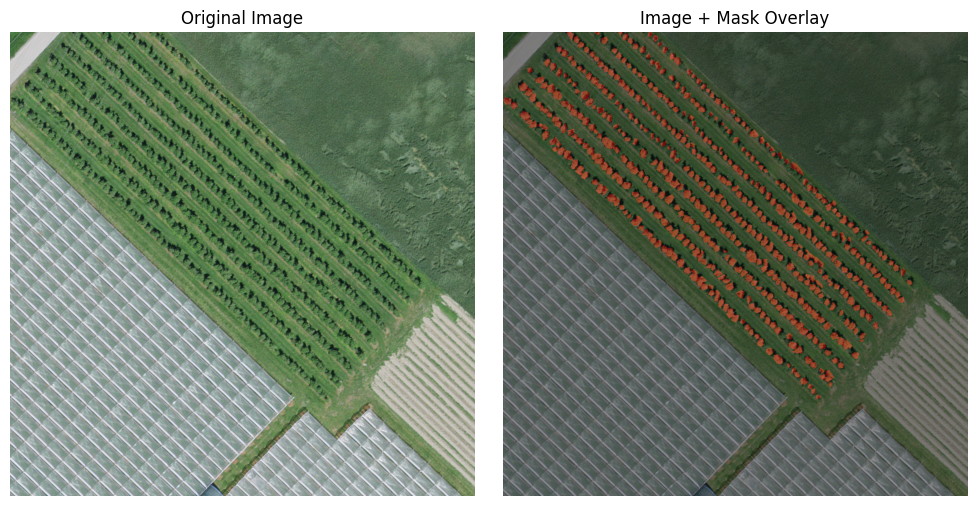

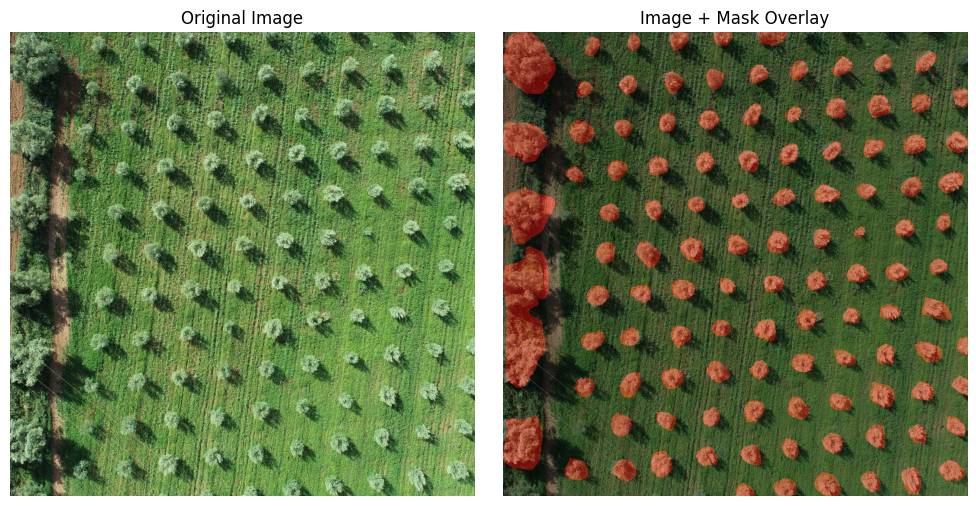

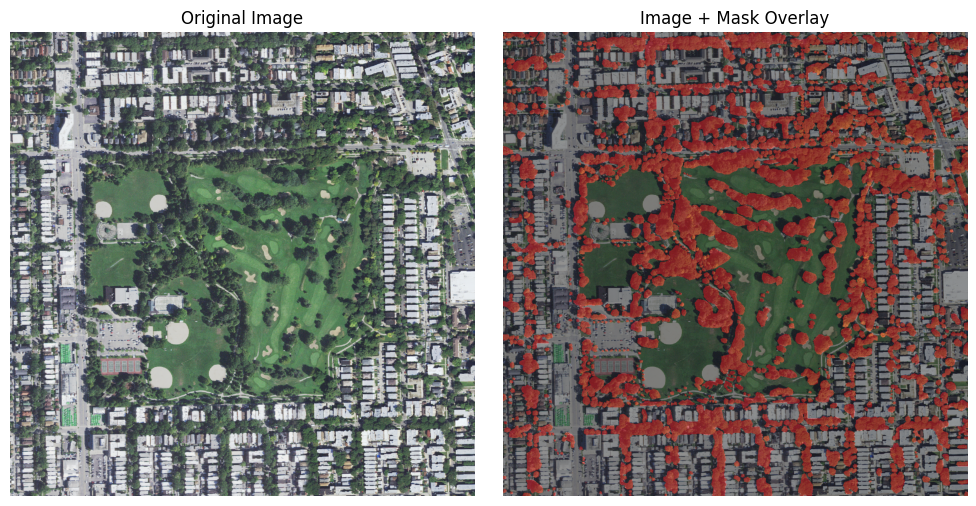

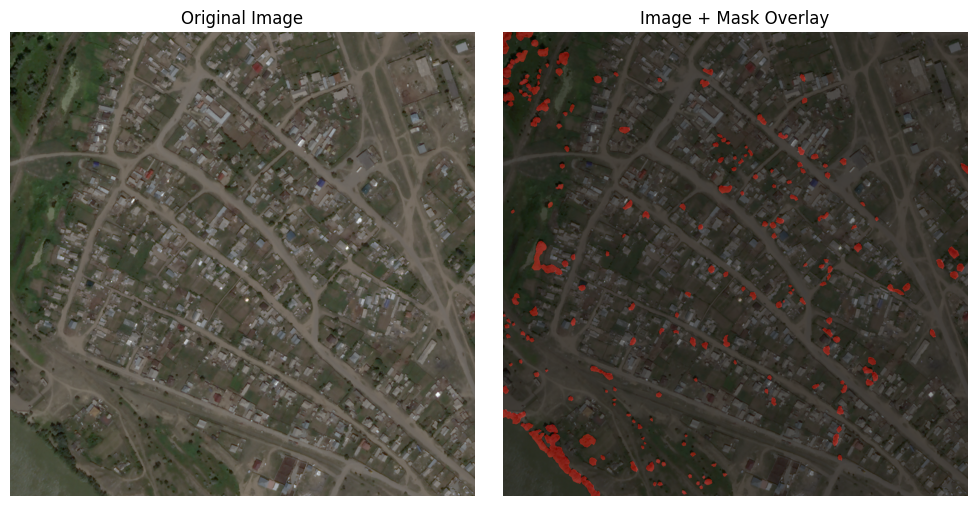

In [15]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def show_image_with_mask(image_path, mask_path, alpha=0.4):
    """
    Display an image and its mask overlayed.
    alpha controls mask transparency (0 = invisible, 1 = opaque).
    """
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Failed to read image: {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"Failed to read mask: {mask_path}")
        return

    # Create red overlay for mask
    mask_rgb = np.zeros_like(image)
    mask_rgb[:, :, 0] = mask  # Red channel

    overlay = cv2.addWeighted(image, 1 - alpha, mask_rgb, alpha, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Image + Mask Overlay")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


sample_img = sorted(list(PATHS_TRAIN_IMAGES.glob("*")))[0]
sample_mask = PATHS_TRAIN_MASKS / sample_img.name
show_image_with_mask(sample_img, sample_mask)

sample_img = sorted(list(PATHS_TRAIN_IMAGES.glob("*")))[10]
sample_mask = PATHS_TRAIN_MASKS / sample_img.name
show_image_with_mask(sample_img, sample_mask)

sample_img = sorted(list(PATHS_TRAIN_IMAGES.glob("*")))[100]
sample_mask = PATHS_TRAIN_MASKS / sample_img.name
show_image_with_mask(sample_img, sample_mask)

sample_img = sorted(list(PATHS_TRAIN_IMAGES.glob("*")))[141]
sample_mask = PATHS_TRAIN_MASKS / sample_img.name
show_image_with_mask(sample_img, sample_mask)

In [10]:
# validate_dataset(train_ds, "train")

Validating train dataset...
train dataset OK (150 samples).


In [16]:
# ---------------------------------------------------------------
# 3. MODEL (U-Net)
# ---------------------------------------------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)
        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))
        c4 = self.enc4(self.pool(c3))
        b = self.bottleneck(self.pool(c4))
        u4 = self.up4(b)
        u4 = torch.cat([u4, c4], dim=1)
        d4 = self.dec4(u4)
        u3 = self.up3(d4)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.dec3(u3)
        u2 = self.up2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2)
        u1 = self.up1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1)
        return torch.sigmoid(self.out(d1))


model = UNet().to(DEVICE)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


p("UNet", model)

UNet: UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, ker

In [18]:
from PIL import Image


def validate_dataset(ds, name):
    print(f"Validating {name} dataset...")
    for i in range(min(20, len(ds))):  # check first few samples
        try:
            img, mask = ds[i]
        except Exception as e:
            print(f"Error at index {i}: {e}")
            raise
    print(f"{name} dataset OK ({len(ds)} samples).")


validate_dataset(train_ds, "train")
# validate_dataset(val_ds, "val")

Validating train dataset...
train dataset OK (150 samples).


In [19]:
# ---------------------------------------------------------------
# 4. TRAINING
# ---------------------------------------------------------------
import os
from pathlib import Path

import torch
from tqdm import tqdm


def train_epoch(loader):
    model.train()
    loss_sum = 0
    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        try:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            loss = criterion(preds, masks)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        except Exception as e:
            print(f"Error during training batch: {e}")
            break
    return loss_sum / max(1, len(loader))


def val_epoch(loader):
    model.eval()
    loss_sum = 0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            try:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                preds = model(imgs)
                loss = criterion(preds, masks)
                loss_sum += loss.item()
            except Exception as e:
                print(f"Error during validation batch: {e}")
                break
    return loss_sum / max(1, len(loader))


# --- Training loop ---
for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    try:
        tr_loss = train_epoch(train_loader)
        val_loss = val_epoch(val_loader)
        print(f"Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")
    except Exception as e:
        print(f"Error in epoch {epoch}: {e}")
        break

# --- Save model ---
model_path = PATHS_MODELS / "unet_canopy.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path.relative_to(ROOT)}")


Epoch 1/20


Error during training batch: Input type (unsigned char) and bias type (float) should be the same


Error in epoch 1: too many values to unpack (expected 2)
Model saved to models\unet_canopy.pth


In [20]:
# ---------------------------------------------------------------
# 5. INFERENCE EXAMPLE
# ---------------------------------------------------------------
model.eval()
sample_img = os.listdir(PATHS_EVAL_IMAGES)[0]
img = cv2.imread(os.path.join(PATHS_EVAL_IMAGES, sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
aug = val_transform(image=img)
img_tensor = aug["image"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = model(img_tensor).squeeze().cpu().numpy()
mask = (pred > 0.5).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Predicted Tree Canopy Mask")
plt.axis("off")
plt.show()

RuntimeError: Input type (unsigned char) and bias type (float) should be the same